## Outlier Detection using Z score method

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### The dataset has 2 independent features cgpa and placement_exam_marks.

In [3]:
df = pd.read_csv('./../data/placement_dataset.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
df.shape

(1000, 3)

In [5]:
df.info

<bound method DataFrame.info of      cgpa  placement_exam_marks  placed
0    7.19                  26.0       1
1    7.46                  38.0       1
2    7.54                  40.0       1
3    6.42                   8.0       1
4    7.23                  17.0       0
..    ...                   ...     ...
995  8.87                  44.0       1
996  9.12                  65.0       1
997  4.89                  34.0       0
998  8.62                  46.0       1
999  4.90                  10.0       1

[1000 rows x 3 columns]>

<Axes: xlabel='placement_exam_marks', ylabel='Density'>

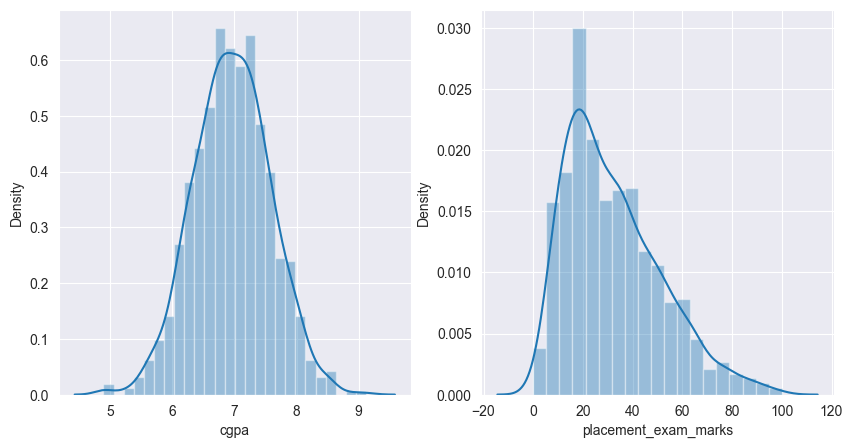

In [6]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

 The distribution of the data shows that the feature cgpa is normally distributed, and the other feature, placemet_exam_marks is skewed.

 So, the feature cgpa qualifies for the Z Score-based method of the outlier detection technique.

In [7]:
print('Mean value of CGPA {}'.format(df['cgpa'].mean()))
print('Min value of CGPA {}'.format(df['cgpa'].min()))
print('Max value of CGPA {}'.format(df['cgpa'].max()))
print('Standard deviation value of CGPA {}'.format(round(df['cgpa'].std(),2)))

Mean value of CGPA 6.96124
Min value of CGPA 4.89
Max value of CGPA 9.12
Standard deviation value of CGPA 0.62


In [8]:
# the boundary values are:
print('Highest value of cgpa', round(df['cgpa'].mean()+3*df['cgpa'].std(),3))
print('Lowest value of cgpa', round(df['cgpa'].mean()-3*df['cgpa'].std(),3))

Highest value of cgpa 8.809
Lowest value of cgpa 5.114


#### Below are the 5 data points which are detected as outliers.

In [9]:
df[(df['cgpa']>8.80) | (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


### This can also be achieved using the Z score formula, which is shown below.

In [10]:
df['cgpa_with_zscore'] = (df['cgpa']-df['cgpa'].mean())/(df['cgpa'].std())

df.head()

,cgpa,placement_exam_marks,placed,cgpa_with_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [11]:
df[(df['cgpa_with_zscore']<-3)|(df['cgpa_with_zscore']>3)]

,cgpa,placement_exam_marks,placed,cgpa_with_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


### Outlier Treatment
### Trimming
#### In this method, we can remove all the data points that are outside the 3 standard deviations.

In [12]:
df_new = df[(df['cgpa']>5.11) & (df['cgpa']<8.80)]

In [13]:
df_new

,cgpa,placement_exam_marks,placed,cgpa_with_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


### Capping
#### In this method, the outlier data points are capped with the highest or lowest values, as shown below.

In [20]:
upper_limit = 8.8
lower_limit = 5.11

df['cgpa'] = np.where(df['cgpa']>upper_limit, upper_limit , df['cgpa'])
df['cgpa'] = np.where(df['cgpa']<lower_limit , lower_limit , df['cgpa'])

In [18]:
df['cgpa'].min()

np.float64(5.11)

In [19]:
df['cgpa'].max()

np.float64(8.8)